In [1]:
# Add project folder to sys.path
import sys
from pathlib import Path
project_path = Path(r"C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor")
sys.path.append(str(project_path))

### Imports

In [2]:
from data_exploration.utils.data_loader import DataLoader
from data_exploration.utils.data_explorer import DataExplorer
from second_term_gpa_regression.utils.data_cleaner_proxy import DataCleaner
from skimpy import skim
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import keras
import tensorflow as tf
from keras_tuner import Hyperband
import shutil
import time

from tensorflow.keras.optimizers import Adam, SGD, RMSprop


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110})

In [3]:
# # Load the original student dataset 
# data_file = project_path / "data/Student data.csv"
# dl = DataLoader(str(data_file))
# structure_df = dl.load_and_clean_data()
# structure_df.columns.to_list()

#  # Save the cleaned dataset structure to a new CSV file
# structure_df.to_csv(project_path / "data/structured_student_data.csv", index=False)

In [4]:
# ------ Helper Classes for Custom Metrics ------
class RMSEMetric(tf.keras.metrics.Metric):
    """Dataset-level RMSE accumulated across batches."""

    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.sse = self.add_weight(name="sse", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        squared_errors = tf.square(y_true - y_pred)
        self.sse.assign_add(tf.reduce_sum(squared_errors))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        return tf.sqrt(tf.math.divide_no_nan(self.sse, self.count))

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

class R2Metric(tf.keras.metrics.Metric):
    """Dataset-level R-squared metric accumulated across batches."""

    def __init__(self, name="r2", **kwargs):
        super().__init__(name=name, **kwargs)
        self.ss_res = self.add_weight(name="ss_res", initializer="zeros")
        self.sum_y = self.add_weight(name="sum_y", initializer="zeros")
        self.sum_y_sq = self.add_weight(name="sum_y_sq", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = tf.reshape(tf.cast(y_true, self.dtype), [-1])
        y_pred = tf.reshape(tf.cast(y_pred, self.dtype), [-1])

        self.ss_res.assign_add(tf.reduce_sum(tf.square(y_true - y_pred)))
        self.sum_y.assign_add(tf.reduce_sum(y_true))
        self.sum_y_sq.assign_add(tf.reduce_sum(tf.square(y_true)))
        self.count.assign_add(tf.cast(tf.size(y_true), self.dtype))

    def result(self):
        ss_tot = self.sum_y_sq - tf.square(self.sum_y) / (self.count + tf.keras.backend.epsilon())
        return 1.0 - tf.math.divide_no_nan(self.ss_res, ss_tot + tf.keras.backend.epsilon())

    def reset_state(self):
        for variable in self.variables:
            variable.assign(0.0)

In [36]:
# ----- Helper Functions -----
def print_header(name):
    """Print a compact section header."""
    print("\n" + f" {name} ".center(72, "=") + "\n")


def custom_callback(monitor, mode, patience, filepath):
    """Early stopping and model checkpoint callbacks for training."""
    es = EarlyStopping(monitor=monitor, patience=patience, restore_best_weights=True, verbose=1, mode=mode)
    mc = ModelCheckpoint(filepath=filepath, monitor=monitor, verbose=1, save_best_only=True, mode=mode)
    return es, mc


def get_target_scale(scaler_obj=None):
    scaler_obj = scaler_obj or globals().get('scaler', None)
    if scaler_obj is None or not hasattr(scaler_obj, 'data_min_') or not hasattr(scaler_obj, 'data_max_'):
        return 1.0
    return float(np.asarray(scaler_obj.data_max_ - scaler_obj.data_min_).ravel()[0])

def evaluate_and_plot_diagnostics(model, X_split, y_split, scaler, split_name='Split', title_prefix=None, verbose=0, print_summary=True, display_top_errors=False, top_n=15):
    metrics, prediction_df = evaluate_model_original_scale(
        model,
        X_split,
        y_split,
        scaler,
        split_name=split_name,
        verbose=verbose,
        print_summary=print_summary,
    )

    if display_top_errors:
        display(prediction_df.head(top_n))

    plot_prediction_diagnostics(prediction_df, title_prefix=title_prefix or split_name)
    return metrics, prediction_df


def plot_regression_history(history, title_prefix='Model', scaler_obj=None):
    target_scale = get_target_scale(scaler_obj)
    mse_scale = target_scale ** 2

    train_mae = np.asarray(history.history['mae']) * target_scale
    val_mae = np.asarray(history.history['val_mae']) * target_scale
    train_loss = np.asarray(history.history['loss']) * mse_scale
    val_loss = np.asarray(history.history['val_loss']) * mse_scale

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(train_mae, label='Train MAE')
    axes[0].plot(val_mae, label='Val MAE')
    axes[0].set(title=f'{title_prefix} MAE', xlabel='Epoch', ylabel='MAE (GPA)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(train_loss, label='Train Loss')
    axes[1].plot(val_loss, label='Val Loss')
    if 'rmse' in history.history:
        axes[1].plot(np.asarray(history.history['rmse']) * target_scale, '--', label='Train RMSE')
        axes[1].plot(np.asarray(history.history['val_rmse']) * target_scale, '--', label='Val RMSE')
    axes[1].set(title=f'{title_prefix} Loss & RMSE', xlabel='Epoch', ylabel='Value (GPA / GPA²)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    if 'r2' in history.history:
        axes[2].plot(history.history['r2'], label='Train R² (Scaled y)')
        axes[2].plot(history.history['val_r2'], label='Val R² (Scaled y)')
        axes[2].set(title=f'{title_prefix} R² (Scaled y)', xlabel='Epoch', ylabel='R²')
        axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best = int(np.argmin(history.history['val_loss']))
    get = lambda values: f"{np.asarray(values)[best]:.4f}"

    print(f"\nBest Epoch: {best + 1}")
    print('-' * 40)
    print(f"MAE (GPA)   -> Train: {get(train_mae)} | Val: {get(val_mae)}")
    if 'rmse' in history.history:
        print(f"RMSE (GPA)  -> Train: {get(np.asarray(history.history['rmse']) * target_scale)} | Val: {get(np.asarray(history.history['val_rmse']) * target_scale)}")
    print(f"Loss (GPA²) -> Train: {get(train_loss)} | Val: {get(val_loss)}")
    if 'r2' in history.history:
        print(f"R² (Scaled y) -> Train: {get(history.history['r2'])} | Val: {get(history.history['val_r2'])}")


def get_optimizer(name, learning_rate):
    if name == 'adam':
        return Adam(learning_rate=learning_rate)
    if name == 'sgd':
        return SGD(learning_rate=learning_rate, momentum=0.9)
    if name == 'rmsprop':
        return RMSprop(learning_rate=learning_rate)
    raise ValueError(f'Unsupported optimizer: {name}')


def build_dense_model(input_dim, layer_specs):
    model = keras.Sequential([keras.layers.Input(shape=(input_dim,))])
    for spec in layer_specs:
        model.add(Dense(spec['units'], activation=spec['activation']))
        if spec.get('batch_norm', False):
            model.add(BatchNormalization())
        if spec.get('dropout', 0.0) > 0:
            model.add(Dropout(spec['dropout']))
    model.add(Dense(1))
    return model


def compile_regression_model(model, optimizer_name, learning_rate):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss='mse',
        metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
    )
    return model


def inverse_transform_target(values, scaler):
    return scaler.inverse_transform(np.asarray(values).reshape(-1, 1)).flatten()


def evaluate_model_original_scale(model, X_split, y_split, scaler, split_name='Split', verbose=0, print_summary=True):
    y_pred_scaled = model.predict(X_split, verbose=verbose).ravel()
    y_true_scaled = np.asarray(y_split).ravel()
    y_true_actual = inverse_transform_target(y_split, scaler)
    y_pred_actual = inverse_transform_target(y_pred_scaled, scaler)
    r2_original = float(r2_score(y_true_actual, y_pred_actual))
    r2_scaled = float(r2_score(y_true_scaled, y_pred_scaled))

    metrics = {
        'split': split_name,
        'rmse': float(mean_squared_error(y_true_actual, y_pred_actual) ** 0.5),
        'mse': float(mean_squared_error(y_true_actual, y_pred_actual)),
        'mae': float(mean_absolute_error(y_true_actual, y_pred_actual)),
        'r2_original': r2_original,
        'r2_scaled': r2_scaled,
    }

    if print_summary:
        print(f"{split_name} RMSE: {metrics['rmse']:.4f}")
        print(f"{split_name} MSE:  {metrics['mse']:.4f}")
        print(f"{split_name} MAE:              {metrics['mae']:.4f}")
        print(f"{split_name} R² (Original GPA): {metrics['r2_original']:.4f}")
        print(f"{split_name} R² (Scaled y):     {metrics['r2_scaled']:.4f}")

    prediction_df = pd.DataFrame({
        'Actual GPA': y_true_actual,
        'Predicted GPA': y_pred_actual,
    })
    prediction_df['Residual'] = prediction_df['Actual GPA'] - prediction_df['Predicted GPA']
    prediction_df['Absolute Error'] = prediction_df['Residual'].abs()
    prediction_df['Squared Error'] = prediction_df['Residual'] ** 2
    prediction_df = prediction_df.sort_values('Absolute Error', ascending=False).reset_index(drop=True)

    return metrics, prediction_df


def format_metrics_display(df):
    return df.rename(columns={
        'rmse': 'RMSE (GPA)',
        'mse': 'MSE (GPA²)',
        'mae': 'MAE (GPA)',
        'r2_original': 'R² (Original GPA)',
        'r2_scaled': 'R² (Scaled y)',
    })


def format_local_search_display(df):
    return df.rename(columns={
        'trial': 'Trial',
        'trial_name': 'Trial Name',
        'optimizer': 'Optimizer',
        'learning_rate': 'Learning Rate',
        'batch_size': 'Batch Size',
        'best_epoch': 'Best Epoch',
        'val_rmse': 'Val RMSE (GPA)',
        'val_mae': 'Val MAE (GPA)',
        'val_r2_original': 'Val R² (Original GPA)',
        'val_r2_scaled': 'Val R² (Scaled y)',
        'test_rmse': 'Test RMSE (GPA)',
        'test_mae': 'Test MAE (GPA)',
        'test_r2_original': 'Test R² (Original GPA)',
        'test_r2_scaled': 'Test R² (Scaled y)',
        'architecture': 'Architecture',
    })


def plot_prediction_diagnostics(prediction_df, title_prefix='Model'):
    actual = prediction_df['Actual GPA']
    predicted = prediction_df['Predicted GPA']
    residuals = prediction_df['Residual']
    plot_min = min(actual.min(), predicted.min())
    plot_max = max(actual.max(), predicted.max())

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(x=actual, y=predicted, color='#4c78a8', alpha=0.65, ax=axes[0])
    axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=1.5)
    axes[0].set_title(f'{title_prefix}: Actual vs Predicted')
    axes[0].set_xlabel('Actual GPA')
    axes[0].set_ylabel('Predicted GPA')
    axes[0].set_xlim(plot_min, plot_max)
    axes[0].set_ylim(plot_min, plot_max)
    axes[0].grid(True, alpha=0.3)

    sns.scatterplot(x=predicted, y=residuals, color='#f58518', alpha=0.65, ax=axes[1])
    axes[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[1].set_title(f'{title_prefix}: Residuals vs Predicted')
    axes[1].set_xlabel('Predicted GPA')
    axes[1].set_ylabel('Residual')
    axes[1].grid(True, alpha=0.3)

    sns.histplot(residuals, bins=20, kde=True, color='#54a24b', ax=axes[2])
    axes[2].axvline(0, color='red', linestyle='--', linewidth=1.2)
    axes[2].set_title(f'{title_prefix}: Residual Distribution')
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Count')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_experiment_comparison(comparison_df):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.barplot(data=comparison_df, x='Model', y='r2_original', hue='Split', palette='Blues', ax=axes[0])
    axes[0].set_title('R² Comparison (Original GPA)')
    axes[0].set_ylabel('R²')
    axes[0].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='r2_scaled', hue='Split', palette='Greens', ax=axes[1])
    axes[1].set_title('R² Comparison (Scaled y)')
    axes[1].set_ylabel('R²')
    axes[1].grid(True, axis='y', alpha=0.3)

    sns.barplot(data=comparison_df, x='Model', y='rmse', hue='Split', palette='Oranges', ax=axes[2])
    axes[2].set_title('RMSE Comparison')
    axes[2].set_ylabel('RMSE (GPA)')
    axes[2].grid(True, axis='y', alpha=0.3)

    axes[1].legend_.remove()
    axes[2].legend_.remove()
    for ax in axes:
        ax.tick_params(axis='x', rotation=12)

    plt.tight_layout()
    plt.show()


def plot_local_search_summary(local_search_results_df, top_n=8):
    plot_df = local_search_results_df.copy()
    top_df = plot_df.head(top_n).copy().sort_values('val_r2_original')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.scatterplot(
        data=plot_df,
        x='val_rmse',
        y='val_r2_original',
        hue='optimizer',
        size='best_epoch',
        sizes=(60, 220),
        palette='viridis',
        ax=axes[0],
    )
    axes[0].set_title('Local Search: Validation RMSE vs R² (Original GPA)')
    axes[0].set_xlabel('Validation RMSE (GPA)')
    axes[0].set_ylabel('Validation R² (Original GPA)')
    axes[0].grid(True, alpha=0.3)

    sns.barplot(data=top_df, x='val_r2_original', y='trial_name', hue='optimizer', dodge=False, palette='Blues', ax=axes[1])
    axes[1].set_title(f'Top {top_n} Local Search Trials')
    axes[1].set_xlabel('Validation R² (Original GPA)')
    axes[1].set_ylabel('Trial')
    axes[1].grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def get_feature_groups(feature_columns):
    base_features = [
        'first_term_gpa',
        'high_school_average_mark',
        'math_score',
        'fast_track',
        'coop',
        'residency',
        'age_group',
        'english_grade',
        'first_language',
        'funding',
        'gender',
        'previous_education',
        'gpa_category',
    ]
    grouped = {}
    assigned = set()

    for feature in base_features:
        cols = [
            col for col in feature_columns
            if col == feature or (col.startswith(f'{feature}_') and not col.endswith('_missing'))
        ]
        if cols:
            grouped[feature] = cols
            assigned.update(cols)

    missing_flag_cols = [col for col in feature_columns if col.endswith('_missing')]
    for col in missing_flag_cols:
        grouped[col] = [col]
        assigned.add(col)

    for col in feature_columns:
        if col not in assigned:
            grouped[col] = [col]

    return grouped


def compute_grouped_permutation_importance(model, X_df, y_scaled, scaler, n_repeats=3, random_state=42, verbose=0):
    feature_groups = get_feature_groups(list(X_df.columns))
    rng = np.random.default_rng(random_state)
    y_true_actual = inverse_transform_target(y_scaled, scaler)
    baseline_pred_actual = inverse_transform_target(model.predict(X_df, verbose=verbose).ravel(), scaler)
    baseline_rmse = mean_squared_error(y_true_actual, baseline_pred_actual) ** 0.5
    baseline_r2 = r2_score(y_true_actual, baseline_pred_actual)

    rows = []
    for group_name, columns in feature_groups.items():
        rmse_increases = []
        r2_drops = []
        for _ in range(n_repeats):
            X_permuted = X_df.copy()
            perm_idx = rng.permutation(len(X_permuted))
            X_permuted.loc[:, columns] = X_permuted.iloc[perm_idx][columns].to_numpy()
            perm_pred_actual = inverse_transform_target(model.predict(X_permuted, verbose=verbose).ravel(), scaler)
            perm_rmse = mean_squared_error(y_true_actual, perm_pred_actual) ** 0.5
            perm_r2 = r2_score(y_true_actual, perm_pred_actual)
            rmse_increases.append(perm_rmse - baseline_rmse)
            r2_drops.append(baseline_r2 - perm_r2)

        rows.append({
            'Feature Group': group_name,
            'RMSE Increase (Mean)': float(np.mean(rmse_increases)),
            'RMSE Increase (Std)': float(np.std(rmse_increases)),
            'R² Drop (Mean)': float(np.mean(r2_drops)),
            'Grouped Columns': ', '.join(columns),
        })

    importance_df = pd.DataFrame(rows).sort_values(['RMSE Increase (Mean)', 'R² Drop (Mean)'], ascending=False).reset_index(drop=True)
    return importance_df


def plot_grouped_feature_importance(importance_df, title='Grouped Feature Importance'):
    plt.figure(figsize=(9, 6))
    sns.barplot(
        data=importance_df.sort_values('RMSE Increase (Mean)'),
        x='RMSE Increase (Mean)',
        y='Feature Group',
        hue='Feature Group',
        palette='crest',
        dodge=False,
        legend=False,
    )
    plt.title(title)
    plt.xlabel('Mean RMSE Increase after Group Permutation')
    plt.ylabel('Feature Group')
    plt.tight_layout()
    plt.show()

### Data Acquisition

In [6]:
#----- Main Code -----#
np.random.seed(42)

# Load the structured dataset
structured_data_file = project_path / "data/structured_student_data.csv"
clean_df = pd.read_csv(structured_data_file)

# Observe the dataset
skim(clean_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ string      │ 8     │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 7     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                    ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ funding                   │   0 │      0 │    2.927 │    1.258 │   1 │    2 │    2 │    4 │     9 │  ▇ ▆   │  │
│ │ school                    │   0 │      0 │        6 │        0 │   6 │    6 │    6 │    6 │     6 │     ▇  │  │
│ │ fast_track                │   0 │      0 │    1.742 │   0.4378 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ coop                      │   0 │      0 │    1.695 │   0.4605 │   1 │    1 │    2 │    2 │     2 │ ▃    ▇ │  │
│ │ residency                 │   0 │      0 │    1.406 │   0.4913 │   1 │    1 │    1 │    2 │     2 │ ▇    ▅ │  │
│ │ gender                    │   0 │      0 │    1.775 │   0.4197 │   1 │    2 │    2 │    2 │     3 │  ▂  ▇  │  │
│ │ first_year_persistence    │   0 │      0 │   0.7919 │   0.4061 │   0 │    1 │    1 │    1 │     1 │ ▂    ▇ │  │
│ └───────────────────────────┴─────┴────────┴──────────┴──────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━┳━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ shortest ┃ longest  ┃ min ┃ max ┃ chars per row ┃ words per row ┃ total words ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━╇━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ first_term_gpa │  0 │    0 │ 0        │ 3.020833 │ 0   │ ?   │          6.16 │             1 │        1437 │  │
│ │ second_term_gp │  0 │    0 │ 0        │ 3.923077 │ 0   │ ?   │          5.81 │             1 │        1437 │  │
│ │ a              │    │      │          │          │     │     │               │               │             │  │
│ │ first_language │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ previous_educa │  0 │    0 │ 1        │ 1        │ 0   │ ?   │             1 │             1 │        1437 │  │
│ │ tion           │    │      │          │          │     │     │               │               │             │  │
│ │ age_group      │  0 │    0 │ 1        │ 1        │ 1   │ ?   │             1 │             1 │        1437 │  │
│ │ high_school_av │  0 │    0 │ ?        │ 101      │ 100 │ ?   │          1.49 │             1 │        1437 │  │
│ │ erage_mark     │    │      │          │          │     │     │               │               │             │  │
│ │ math_score     │  0 │    0 │ ?        │ 16       │ 10  │ ?   │          1.68 │             1 │        1437 │  │
│ │ english_grade  │  0 │    0 │ 7        │ 10       │ 1

In [7]:
# Check the dataset by replacing ? with NaN and drop duplicates -- Cleaning is conducted later by the DataCleaner class
temp_df = clean_df
temp_df = temp_df.replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
skim(temp_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 1437   │ │ float64     │ 15    │                                                          │
│ │ Number of columns │ 15     │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %              ┃ mean   ┃ sd     ┃ p0 ┃ p25  ┃ p50   ┃ p75   ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ first_term_gpa     │  17 │ 1.183020180932498 │  2.846 │  1.175 │  0 │ 2.25 │ 3.103 │ 3.739 │  4.5 │ ▂▁▃▆▇▇ │  │
│ │                    │     │                 3 │        │        │    │      │       │       │      │        │  │
│ │ second_term_gpa    │ 160 │ 11.13430758524704 │   2.82 │  1.129 │  0 │ 2.26 │ 3.028 │  3.68 │  4.5 │ ▂▁▃▆▇▆ │  │
│ │                    │     │                 2 │        │        │    │      │       │       │      │        │  │
│ │ first_language     │ 111 │ 7.724425887265136 │  1.911 │ 0.9949 │  1 │    1 │     1 │     3 │    3 │ ▇    ▇ │  │
│ │ funding            │   0 │                 0 │  2.927 │  1.258 │  1 │    2 │     2 │     4 │    9 │  ▇ ▆   │  │
│ │ school             │   0 │                 0 │      6 │      0 │  6 │    6 │     6 │     6 │    6 │     ▇  │  │
│ │ fast_track         │   0 │                 0 │  1.742 │ 0.4378 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ coop               │   0 │                 0 │  1.695 │ 0.4605 │  1 │    1 │     2 │     2 │    2 │ ▃    ▇ │  │
│ │ residency          │   0 │                 0 │  1.406 │ 0.4913 │  1 │    1 │     1 │     2 │    2 │ ▇    ▅ │  │
│ │ gender             │   0 │                 0 │  1.775 │ 0.4197 │  1 │    2 │     2 │     2 │    3 │  ▂  ▇  │  │
│ │ previous_education │   4 │ 0.278357689631176 │  1.275 │ 0.5678 │  0 │    1 │     1 │     2 │    2 │ ▁  ▇ ▅ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ age_group          │   4 │ 0.278357689631176 │  2.632 │  1.421 │  1 │    2 │     3 │     3 │    8 │ ▇▇▁▁ ▁ │  │
│ │                    │     │                 1 │        │        │    │      │       │       │      │        │  │
│ │ high_school_averag │ 743 │ 51.70494084899095 │  77.15 │  12.07 │ 17 │   70 │  77.5 │    85 │  108 │   ▂▇▇▂ │  │
│ │ e_mark             │     │                   │        │        │    │      │       │       │      │        │  │
│ │ math_score         │ 462 │ 32.15031315240083 │  32.56 │  10.71 │  6 │   23 │    32 │    43 │   50 │ ▁▅▇▇▅▇ │  │
│ │                    │     │                 4 │        │        │    │      │       │       │      │        │  │
│ │ english_grade      │  45 │ 3.131524008350730 │   8.03 │  1.716 │  1 │    7 │     8 │     9 │   10 │   ▁ ▇▇ │  │
│ │                    │     │                 5 │        │        │    │      │       │       │      │        │  │
│ │ first_year_persist │   0 │                 0 │ 0.7919 │ 0.4061 │  0 │    1 │     1 │     1 │    1 │ ▂    ▇ │  │
│ │ ence               │     │                   │      

In [8]:
# replace ? with nan in second_term_gpa column
clean_df["first_term_gpa"] = clean_df["first_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
clean_df["second_term_gpa"] = clean_df["second_term_gpa"].replace("?", np.nan).apply(pd.to_numeric, errors="coerce")
print(f"Number of rows with nulls in first_term_gpa: {clean_df['first_term_gpa'].isna().sum()}")
print(f"Number of rows with nulls in second_term_gpa: {clean_df['second_term_gpa'].isna().sum()}")

clean_df = clean_df.dropna(subset=["second_term_gpa"])
clean_df = clean_df.dropna(subset=["first_term_gpa"])
print(f"Number of rows after dropping nulls in both first and second term GPA variables: {clean_df.shape[0]}")

Number of rows with nulls in first_term_gpa: 17
Number of rows with nulls in second_term_gpa: 160
Number of rows after dropping nulls in both first and second term GPA variables: 1277


In [9]:
# Synthetic proxy for third-term GPA (relay model):
# Weighted progression from first- and second-term GPA,
# conditioned on first-year persistence (non-persistent students assigned 0)
clean_df["third_term_gpa_proxy"] = (
    0.6 * clean_df["second_term_gpa"] + 0.4 * clean_df["first_term_gpa"]
) * clean_df["first_year_persistence"]

# Feature and target separation
y = clean_df["third_term_gpa_proxy"] # third_term_gpa_proxy 
X = clean_df.drop(columns=["school", "third_term_gpa_proxy"]) # Drop school - unique value; avoid target variable for relay version

### Data Exploration

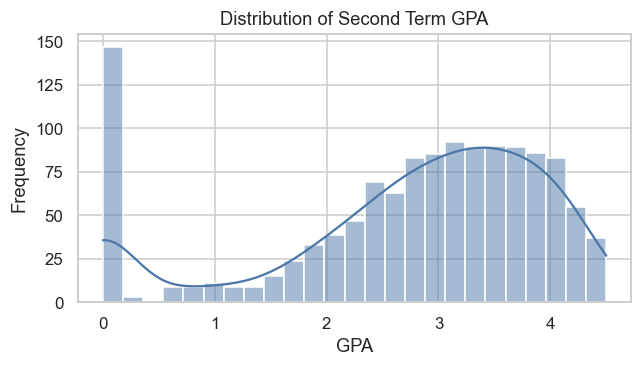

In [10]:
# explorer = DataExplorer(structured_data_file)
# explorer.run_full_analysis()

# Analyze target variable distribution
plt.figure(figsize=(6,3.5))

sns.histplot(y, bins=25, kde=True, color="#4c78a8")
plt.title("Distribution of Second Term GPA")
plt.xlabel("GPA")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [11]:
# number of students have value 0 in second_term_gpa column
num_zero_gpa = (y == 0).sum()
print(f"Number of students with second term GPA of 0: {num_zero_gpa}")

Number of students with second term GPA of 0: 145


### Train-Test Protocol

In [12]:
# test-train split with stratification and train-only feature fitting
X_train_raw, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.125,  # 10% of total
    random_state=42,
)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X_train: (893, 14), X_val: (128, 14), X_test: (256, 14)


In [13]:
# check the final training dataset
display(X_train.head())

,first_term_gpa,second_term_gpa,first_language,funding,fast_track,coop,residency,gender,previous_education,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence
78,3.521739,3.288462,3,4.0,1.0,2.0,2.0,1.0,1,3,?,?,7,1.0
353,2.250000,2.200000,1,2.0,2.0,2.0,1.0,2.0,2,2,83,?,7,1.0
1354,3.400000,3.386364,3,4.0,1.0,2.0,2.0,1.0,2,4,?,?,8,1.0
510,4.214286,4.152174,1,2.0,2.0,1.0,1.0,2.0,2,4,73,49,9,1.0
338,2.547619,2.891304,1,2.0,2.0,1.0,1.0,2.0,1,2,78,27,9,0.0


### Data Cleaning

In [14]:
# Data cleaning
cleaner = DataCleaner(numeric_imputer="bayesian")

X_train = cleaner.fit_transform(X_train)
X_val = cleaner.transform(X_val)
X_test = cleaner.transform(X_test)

# Target standardization
scaler = MinMaxScaler()
y_train = scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_val = scaler.transform(y_val.values.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.values.reshape(-1, 1)).flatten()


In [15]:
import joblib

# save the preprocessing pipeline (DataCleaner object) to a file for later use in inference
joblib.dump(cleaner, project_path / "second_term_gpa_regression" / "models" / 'best_third_term_regression_model' / "third_term_preprocessing_pipeline.pkl")
joblib.dump(scaler, project_path / "second_term_gpa_regression" / "models" / 'best_third_term_regression_model' / "third_term_target_scaler.pkl")

# check the training after cleaning
display(X_train.head())

,first_term_gpa,second_term_gpa,fast_track,coop,residency,age_group,high_school_average_mark,math_score,english_grade,first_year_persistence,...,gender_1,gender_2,previous_education_0,previous_education_1,previous_education_2,previous_education_3,gpa_category_0,gpa_category_1,gpa_category_2,gpa_category_3
78,0.486738,0.416722,1,0,0,3.0,0.338587,0.254614,7.0,1.0,...,True,False,False,True,False,False,False,False,False,True
353,-0.764013,-0.525718,0,0,1,2.0,0.250235,0.103456,7.0,1.0,...,False,True,False,False,True,False,False,False,True,False
1354,0.367008,0.501490,1,0,0,4.0,0.300803,0.230263,8.0,1.0,...,True,False,False,False,True,False,False,False,False,True
510,1.167855,1.164563,0,1,1,4.0,-0.772696,1.662716,9.0,1.0,...,False,True,False,False,True,False,False,False,False,True
338,-0.471306,0.072844,0,1,1,2.0,-0.261231,-0.712049,9.0,0.0,...,False,True,False,True,False,False,False,False,True,False


### Experiment 1: Baseline Model

In [16]:
baseline_layers = [
    {'units': 516, 'activation': 'tanh', 'batch_norm': True, 'dropout': 0.1},
    {'units': 128, 'activation': 'elu', 'batch_norm': True, 'dropout': 0.2},
]

baseline_model = build_dense_model(X_train.shape[1], baseline_layers)
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 516)                 │          17,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 516)                 │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 516)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          66,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,425 (337.60 KB)

 Trainable params: 85,137 (332.57 KB)

 Non-trainable params: 1,288 (5.03 KB)

In [17]:
baseline_model = compile_regression_model(baseline_model, optimizer_name='sgd', learning_rate=0.0009)

baseline_es, baseline_mc = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'best_third_term_regression_model' / 'third_term_regression_model.keras',
)

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[baseline_es, baseline_mc],
    verbose=1,
)

Epoch 1/200
22/28 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8913 - mae: 1.0863 - r2: -21.6985 - rmse: 1.3666
Epoch 1: val_loss improved from None to 0.08628, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\third_term_regression_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\third_term_regression_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 1.2904 - mae: 0.8791 - r2: -14.6652 - rmse: 1.1360 - val_loss: 0.0863 - val_mae: 0.2150 - val_r2: -0.0946 - val_rmse: 0.2937
Epoch 2/200
22/28 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4522 - mae: 0.5347 - r2: -4.6410 - rmse: 0.6707
Epoch 2: val_loss did not improve from 0.08628
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3571 - mae: 0.4677 - r2: -3.3355 - rmse: 0.5976 - val_loss: 0.1053 - val_mae: 0.2508 - val_r2: -0

### Baseline Evaluation

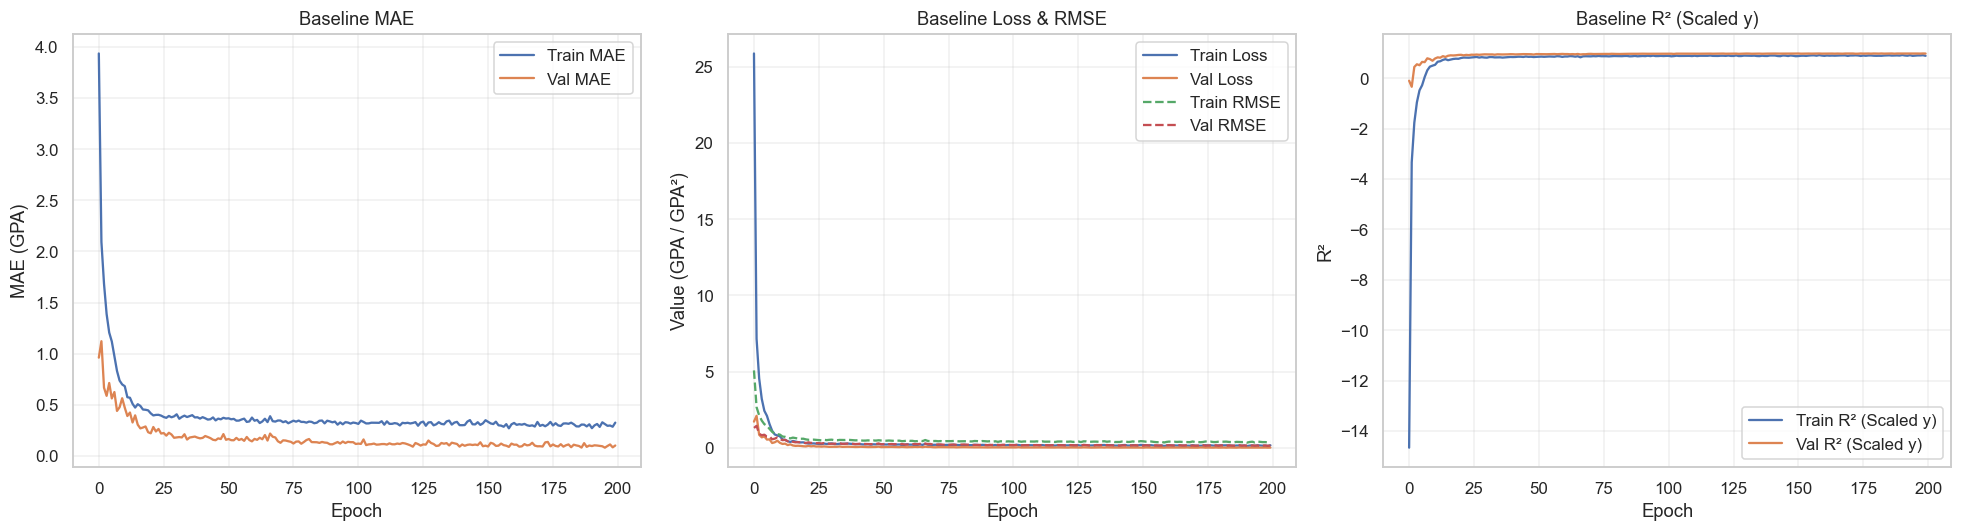


Best Epoch: 183
----------------------------------------
MAE (GPA)   -> Train: 0.3265 | Val: 0.0869
RMSE (GPA)  -> Train: 0.4173 | Val: 0.1440
Loss (GPA²) -> Train: 0.1742 | Val: 0.0207
R² (Scaled y) -> Train: 0.8945 | Val: 0.9869


In [18]:
plot_regression_history(history_baseline, title_prefix='Baseline')

In [23]:
baseline_val_metrics, baseline_val_df = evaluate_model_original_scale(
    baseline_model, X_val, y_val, scaler, split_name='Baseline Validation'
)
baseline_test_metrics, baseline_test_df = evaluate_model_original_scale(
    baseline_model, X_test, y_test, scaler, split_name='Baseline Test'
)

baseline_summary_df = pd.DataFrame([baseline_val_metrics, baseline_test_metrics]).set_index('split')
display(format_metrics_display(baseline_summary_df))
display(baseline_test_df.head(15))

# save the test test as csv for later analysis
baseline_test_df.to_csv(project_path / 'second_term_gpa_regression' / 'data' / 'baseline_test_results.csv', index=False)

Baseline Validation RMSE: 0.1440
Baseline Validation MSE:  0.0207
Baseline Validation MAE:              0.0869
Baseline Validation R² (Original GPA): 0.9869
Baseline Validation R² (Scaled y):     0.9869
Baseline Test RMSE: 0.1514
Baseline Test MSE:  0.0229
Baseline Test MAE:              0.0942
Baseline Test R² (Original GPA): 0.9840
Baseline Test R² (Scaled y):     0.9840


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline Validation,0.143995,0.020735,0.086940,0.986875,0.986875
Baseline Test,0.151422,0.022928,0.094233,0.984038,0.984038


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,0.000000,0.751122,-0.751122,0.751122,0.564184
1,0.000000,0.729804,-0.729804,0.729804,0.532614
2,0.217391,0.923123,-0.705732,0.705732,0.498057
3,0.540000,1.170771,-0.630771,0.630771,0.397872
4,0.428572,0.896678,-0.468107,0.468107,0.219124
5,0.000000,0.459133,-0.459133,0.459133,0.210803
6,0.000000,0.429196,-0.429196,0.429196,0.184209
7,0.000000,0.417203,-0.417203,0.417203,0.174058
8,0.000000,0.417092,-0.417092,0.417092,0.173966
9,0.000000,-0.417010,0.417010,0.417010,0.173898


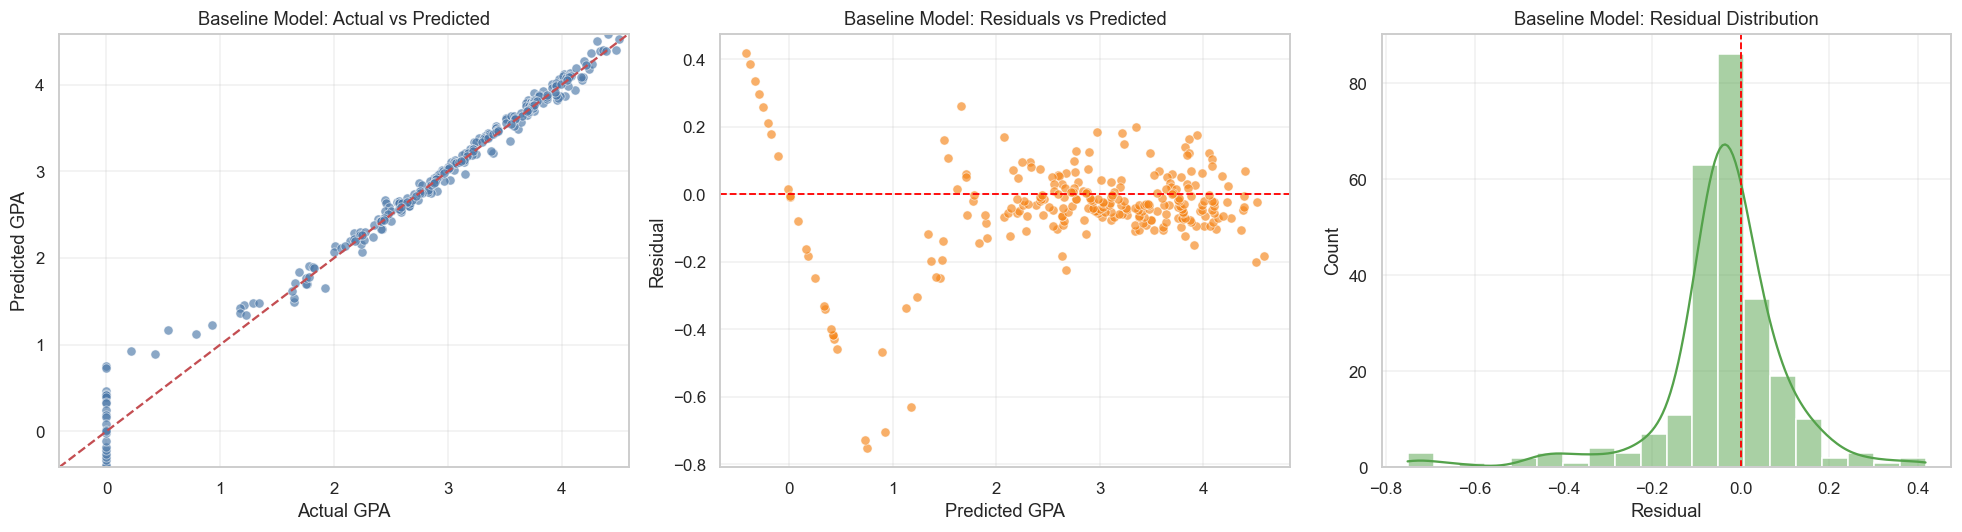

In [20]:
plot_prediction_diagnostics(baseline_test_df, title_prefix='Baseline Model')

### Experiment 2: Baseline Model - LSTM with Bayesian Imputation

In [38]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# reshape to 3D: (samples, timesteps, features_per_timestep)
X_train_lstm = np.asarray(X_train, dtype=np.float32).reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_lstm   = np.asarray(X_val, dtype=np.float32).reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_lstm  = np.asarray(X_test, dtype=np.float32).reshape(X_test.shape[0], X_test.shape[1], 1)

y_train_lstm = np.asarray(y_train, dtype=np.float32)
y_val_lstm   = np.asarray(y_val, dtype=np.float32)
y_test_lstm  = np.asarray(y_test, dtype=np.float32)

baseline_lstm = Sequential([
    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),

    LSTM(516, activation="tanh", return_sequences=True),
    BatchNormalization(),
    Dropout(0.1),

    LSTM(128, activation="elu", return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    LSTM(32, activation="elu"),
    Dense(1)
])

baseline_lstm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 33, 516)             │       1,069,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 33, 516)             │           2,064 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 33, 516)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 33, 128)             │         330,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 33, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 33, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 32)                  │          20,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,422,609 (5.43 MB)

 Trainable params: 1,421,321 (5.42 MB)

 Non-trainable params: 1,288 (5.03 KB)

In [ ]:
baseline_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', RMSEMetric(name='rmse'), R2Metric(name='r2')]
)

es_lstm, mc_lstm = custom_callback(
    monitor='val_loss',
    mode='min',
    patience=20,
    filepath=project_path / 'second_term_gpa_regression' / 'models' / 'lstm_third_term_baseline_model.keras'
)

history_lstm = baseline_lstm.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_val_lstm, y_val_lstm),
    epochs=100,
    batch_size=32,
    callbacks=[es_lstm, mc_lstm],
    verbose=1
)

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 2.7386 - mae: 0.9771 - r2: -33.7910 - rmse: 1.6132
Epoch 1: val_loss improved from None to 0.27771, saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras

Epoch 1: finished saving model to C:\Users\Vivek K\Haripriya\Sem_5\Neural Networks\Final_Project\student-success-predictor\second_term_gpa_regression\models\lstm_baseline_model.keras
28/28 ━━━━━━━━━━━━━━━━━━━━ 34s 372ms/step - loss: 3.1387 - mae: 1.0990 - r2: -37.1027 - rmse: 1.7716 - val_loss: 0.2777 - val_mae: 0.4841 - val_r2: -2.5234 - val_rmse: 0.5270
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 1.5888 - mae: 0.8295 - r2: -18.5849 - rmse: 1.2328
Epoch 2: val_loss did not improve from 0.27771
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - loss: 1.0274 - mae: 0.6962 - r2: -11.4724 - rmse: 1.0136 - val_loss: 0.3970 - val_mae: 0.5725 - val_r2: -4.0364 -

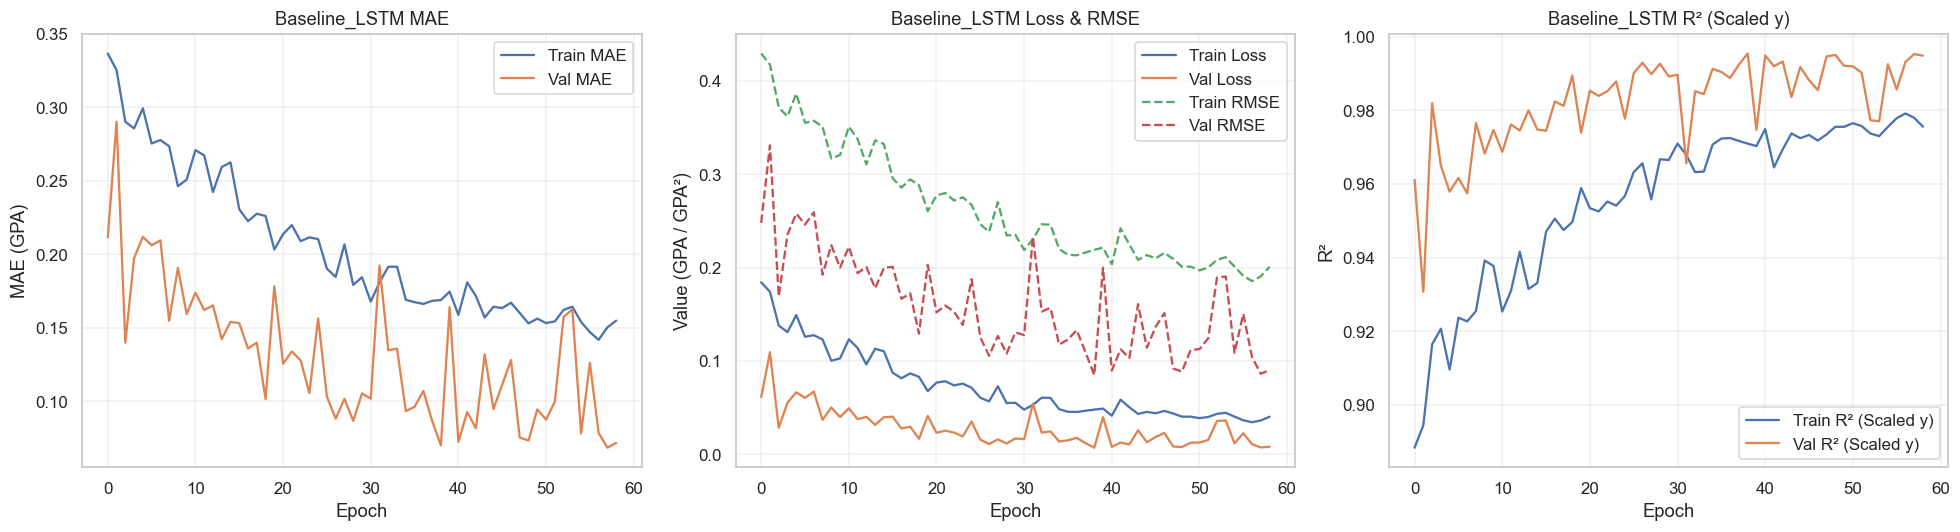


Best Epoch: 39
----------------------------------------
MAE (GPA)   -> Train: 0.1688 | Val: 0.0699
RMSE (GPA)  -> Train: 0.2190 | Val: 0.0849
Loss (GPA²) -> Train: 0.0479 | Val: 0.0072
R² (Scaled y) -> Train: 0.9710 | Val: 0.9954


In [ ]:
plot_regression_history(history_lstm, title_prefix='Baseline_LSTM')

In [ ]:
baseline_lstm_val_metrics, baseline_lstm_val_df = evaluate_model_original_scale(
    baseline_lstm, X_val_lstm, y_val_lstm, scaler, split_name='Baseline LSTM Validation'
)
baseline_lstm_test_metrics, baseline_lstm_test_df = evaluate_model_original_scale(
    baseline_lstm, X_test_lstm, y_test_lstm, scaler, split_name='Baseline LSTM Test'
)

baseline_lstm_summary_df = pd.DataFrame([baseline_lstm_val_metrics, baseline_lstm_test_metrics]).set_index('split')
display(format_metrics_display(baseline_lstm_summary_df))
display(baseline_lstm_test_df.head(15))

Baseline LSTM Validation RMSE: 0.0849
Baseline LSTM Validation MSE:  0.0072
Baseline LSTM Validation MAE:              0.0699
Baseline LSTM Validation R² (Original GPA): 0.9954
Baseline LSTM Validation R² (Scaled y):     0.9954
Baseline LSTM Test RMSE: 0.0898
Baseline LSTM Test MSE:  0.0081
Baseline LSTM Test MAE:              0.0689
Baseline LSTM Test R² (Original GPA): 0.9944
Baseline LSTM Test R² (Scaled y):     0.9944


,RMSE (GPA),MSE (GPA²),MAE (GPA),R² (Original GPA),R² (Scaled y)
split,,,,,
Baseline LSTM Validation,0.084861,0.007201,0.069938,0.995441,0.995441
Baseline LSTM Test,0.089763,0.008057,0.068903,0.994391,0.994391


,Actual GPA,Predicted GPA,Residual,Absolute Error,Squared Error
0,3.021739,3.319581,-0.297841,0.297841,0.088709
1,1.918182,2.168180,-0.249998,0.249998,0.062499
2,0.000000,0.248909,-0.248909,0.248909,0.061956
3,0.217391,0.445335,-0.227944,0.227944,0.051958
4,2.241667,2.466499,-0.224832,0.224832,0.050549
5,1.755114,1.973945,-0.218831,0.218831,0.047887
6,1.172727,0.963919,0.208808,0.208808,0.043601
7,1.825466,1.617803,0.207663,0.207663,0.043124
8,1.812308,1.607110,0.205198,0.205198,0.042106
9,2.173913,2.376082,-0.202169,0.202169,0.040872


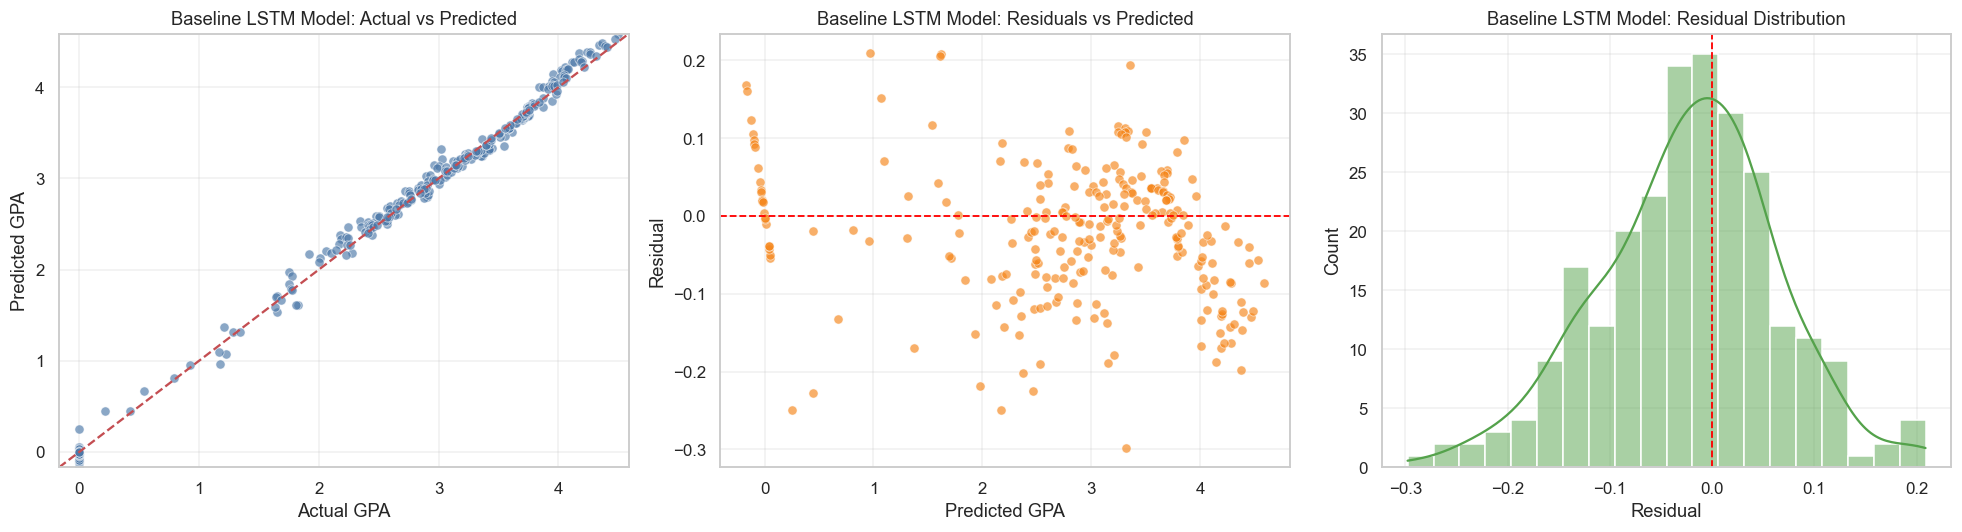

In [ ]:
_, baseline_lstm_diag_df = evaluate_and_plot_diagnostics(
    baseline_lstm,
    X_test_lstm,
    y_test_lstm,
    scaler,
    split_name='Baseline LSTM Test',
    title_prefix='Baseline LSTM Model',
    print_summary=False,
)